In [ ]:
!pip install sumolib traci
!sudo add-apt-repository ppa:sumo/stable
!sudo apt-get update
!sudo apt-get install sumo sumo-tools sumo-doc
import os
os.environ["SUMO_HOME"] = "/usr/share/sumo"
#!which sumo
!sumo --version



Repository: 'deb https://ppa.launchpadcontent.net/sumo/stable/ubuntu/ jammy main'
Description:
SUMO is a highly portable, microscopic traffic simulation package designed to handle large road networks. SUMO is open source, licensed under the EPLv2.
More info: https://launchpad.net/~sumo/+archive/ubuntu/stable
Adding repository.
Press [ENTER] to continue or Ctrl-c to cancel.
Found existing deb entry in /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Adding deb entry to /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Found existing deb-src entry in /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Adding key to /etc/apt/trusted.gpg.d/sumo-ubuntu-stable.gpg with fingerprint 7604B28616B7E70EC0E6D840C32412BB1ADB414B
Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvid

SPEED AND QUEUE

In [ ]:
import traci
import math
import time
import csv
import os

# Define the tracking points (junctions with circles)
tracking_points = [
    (1152.42, 1127.79, 50.0, "FP_A"),
    (950.87, 810.02, 50.0, "FP_B"),
    (1223.24, 631.01, 50.0, "FP_C"),
    (1432.75, 948.52, 50.0, "FP_D"),
    (1740.61, 719.02, 50.0, "KR_Circle"),
    (766.83, 538.53, 50.0, "KG_Road"),
    (1101.36, 389.54, 75.0, "District_Office"),
    (383.71, 1249.29, 50.0, "Anand_Rao_Jnc"),
    (1176.84, 1667.69, 70.0, "Race_Course_Jnc"),
    (1836.39, 1677.60, 50.0, "Palace_Road_Jnc")
]

path = r"/content/osm.sumocfg"
# Output CSV file
output_csv = "/content/junction_stats.csv"
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    # Prepare headers
    headers = ["Time"]
    for _, _, _, name in tracking_points:
        headers.append(f"{name}_Queue")
        headers.append(f"{name}_Speed")
    writer.writerow(headers)

    # Start SUMO
    traci.start(["sumo", "-c", path, "--start"])
    time.sleep(2)
    traci.simulation.setScale(10)

    # Edge mapping
    def is_edge_inside_circle(edge_id, x_center, y_center, radius):
        try:
            from_junc = traci.edge.getFromJunction(edge_id)
            to_junc = traci.edge.getToJunction(edge_id)
            x_from, y_from = traci.junction.getPosition(from_junc)
            x_to, y_to = traci.junction.getPosition(to_junc)
            return (
                math.hypot(x_from - x_center, y_from - y_center) <= radius or
                math.hypot(x_to - x_center, y_to - y_center) <= radius
            )
        except:
            return False

    junction_edges_map = {name: [] for _, _, _, name in tracking_points}
    for edge_id in traci.edge.getIDList():
        for x, y, radius, name in tracking_points:
            if is_edge_inside_circle(edge_id, x, y, radius):
                junction_edges_map[name].append(edge_id)

    def get_queue_length_percentage(edge_id):
        try:
            queue_length = traci.edge.getLastStepVehicleNumber(edge_id)
            lane_id = edge_id + "_0"
            total_length = traci.lane.getLength(lane_id)
            return (queue_length / total_length) * 100 if total_length > 0 else 0
        except:
            return 0

    # Run simulation
    for t in range(4000):
        if (t%100 == 0):
          print(t)
        traci.simulationStep()
        row = [t]

        for x, y, radius, name in tracking_points:
            # Queue Length
            edges = junction_edges_map[name]
            total_pct = sum(get_queue_length_percentage(eid) for eid in edges)
            avg_queue = total_pct / len(edges) if edges else 0

            # Speed
            count = 0
            speed_sum = 0.0
            for vehicle_id in traci.vehicle.getIDList():
                vx, vy = traci.vehicle.getPosition(vehicle_id)
                distance = math.hypot(vx - x, vy - y)
                if distance <= radius:
                    count += 1
                    speed_sum += traci.vehicle.getSpeed(vehicle_id)
            avg_speed = (speed_sum / count) if count > 0 else 0.0

            row.extend([round(avg_queue, 2), round(avg_speed, 2)])

        writer.writerow(row)
        #time.sleep(0.05)

    traci.close()


 Retrying in 1 seconds
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900


In [ ]:
traci.close()

BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
file = r"/content/junction_stats.csv"
import pandas as pd

data = pd.read_csv(file)

summary = data.describe()
print(summary)


              Time   FP_A_Queue   FP_A_Speed   FP_B_Queue   FP_B_Speed  \
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.000000   
mean   1999.500000    39.335360     1.632598     4.081158     1.630063   
std    1154.844867    20.932134     4.657854     2.021204     3.022728   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%     999.750000    22.052500     0.000000     1.880000     0.000000   
50%    1999.500000    43.620000     0.040000     5.040000     0.000000   
75%    2999.250000    51.450000     0.280000     5.482500     1.790000   
max    3999.000000    82.960000    31.080000     7.990000    21.170000   

        FP_C_Queue   FP_C_Speed   FP_D_Queue   FP_D_Speed  KR_Circle_Queue  \
count  4000.000000  4000.000000  4000.000000  4000.000000      4000.000000   
mean      5.167703     1.197653    16.461720     1.881220        15.173730   
std       1.866497     3.448433     8.555812     5.301053         7.566494   
min       0.000000   

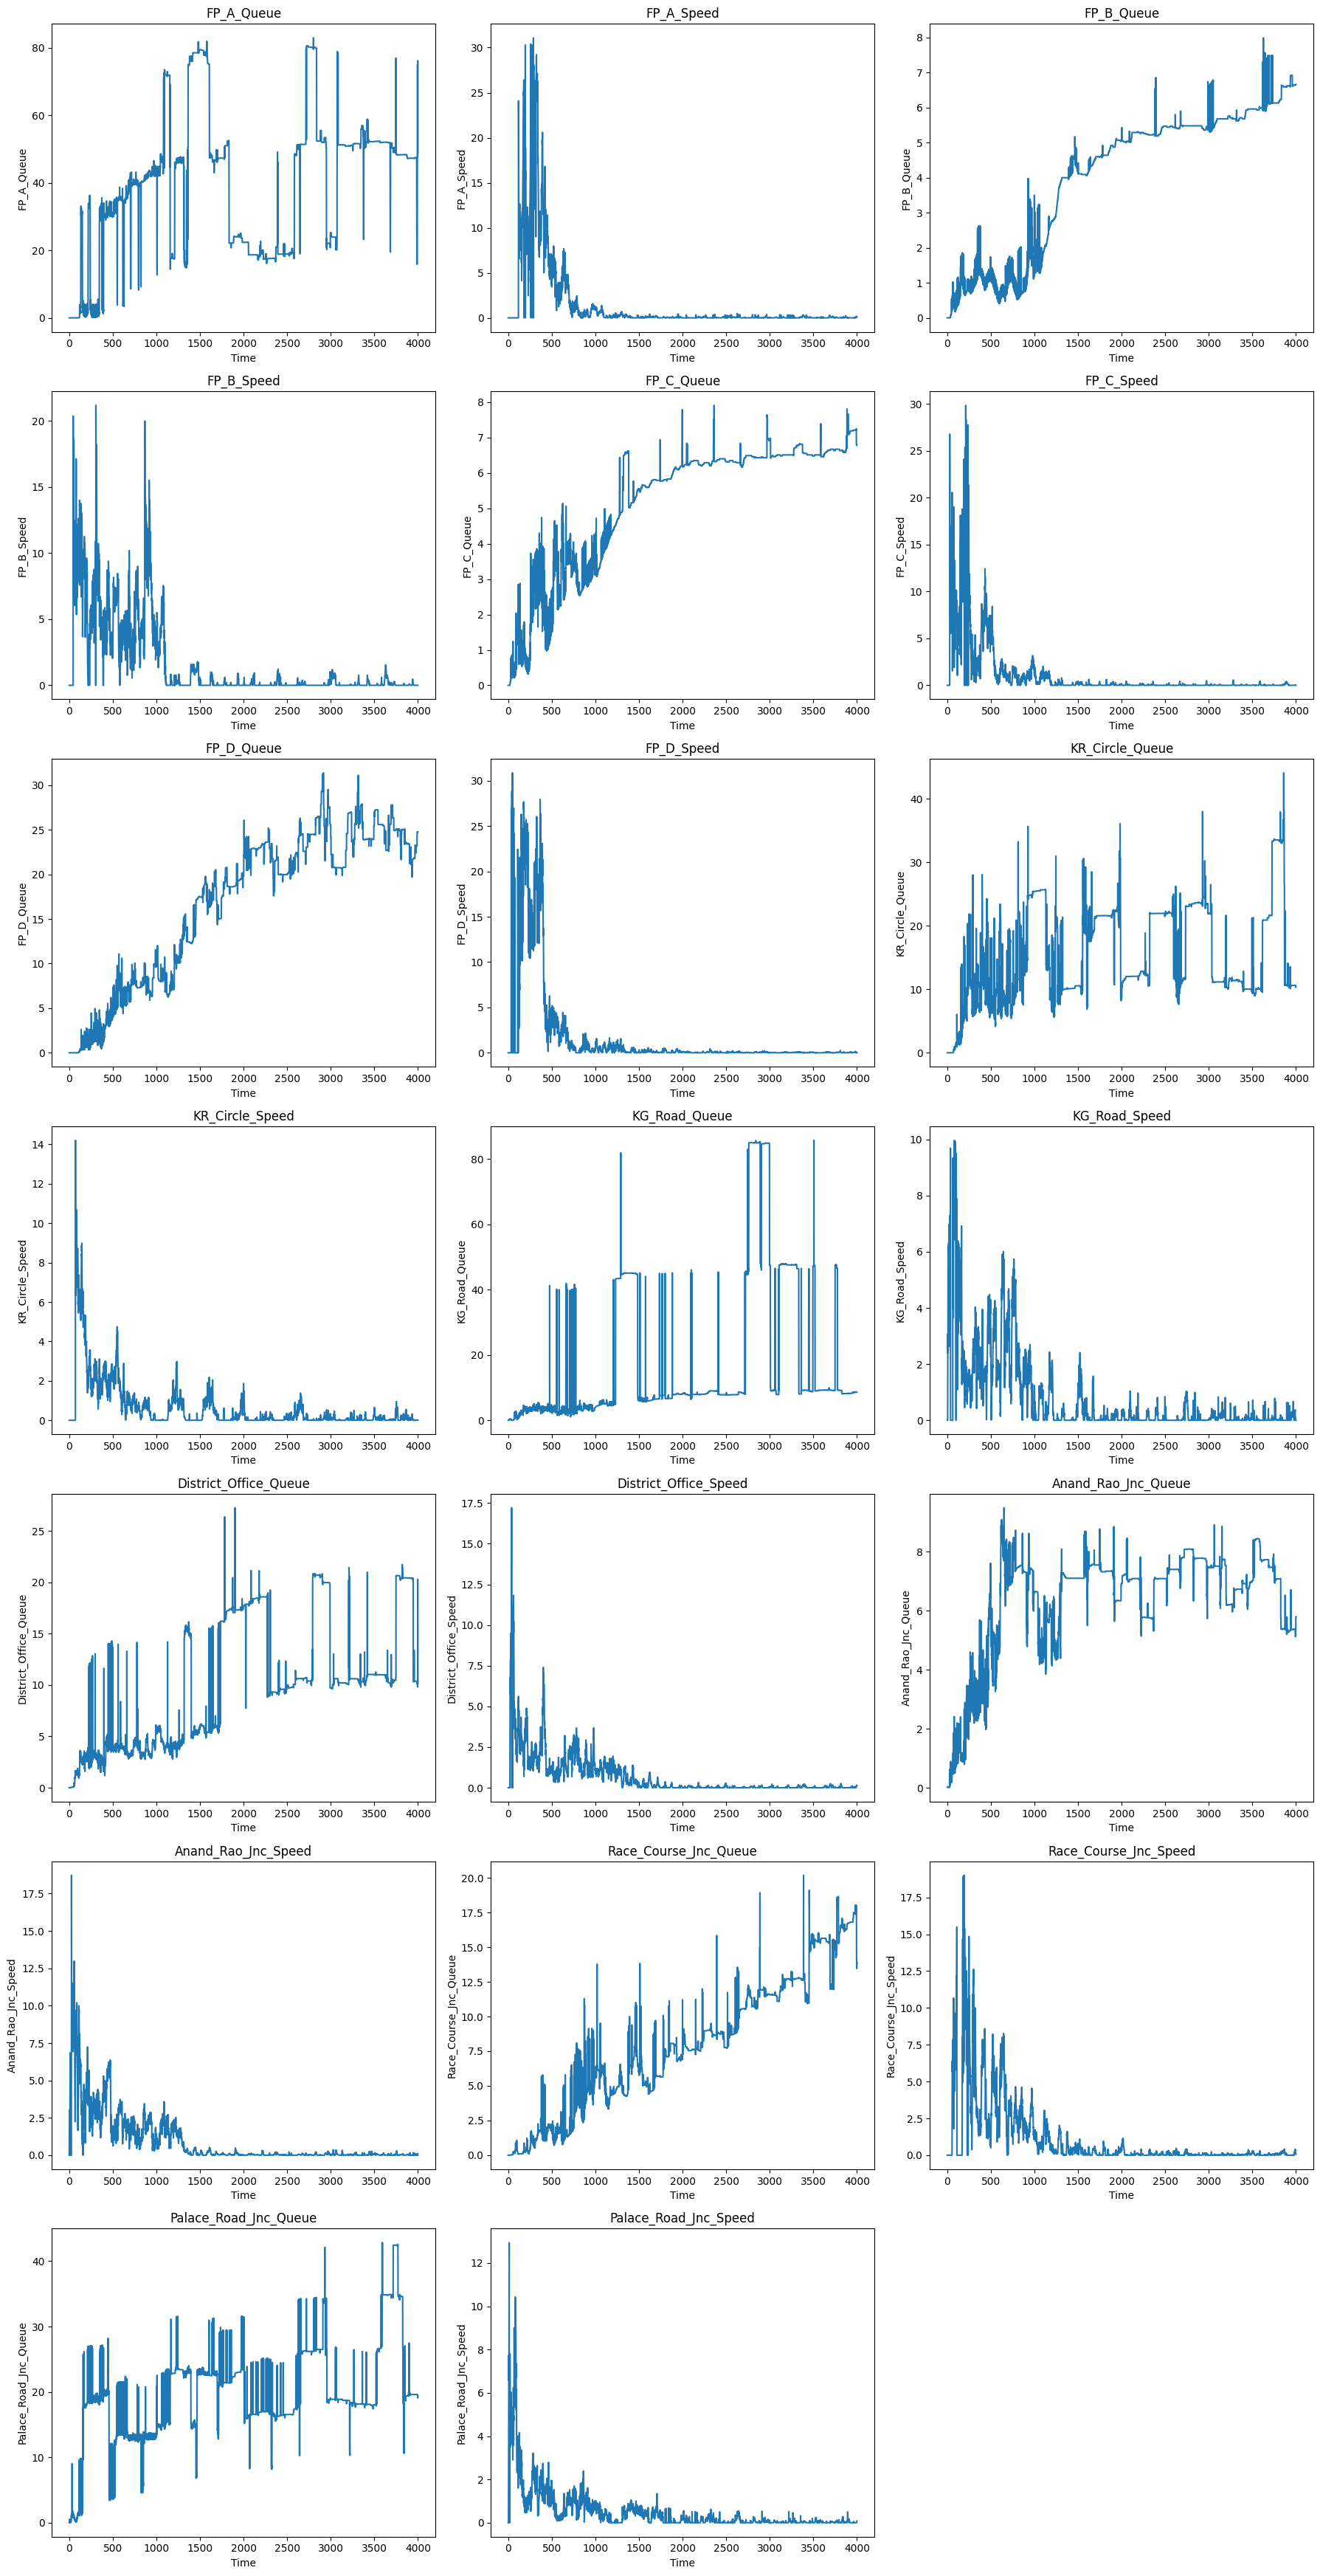

In [ ]:
import matplotlib.pyplot as plt

# Drop Time column if it's just the index
plot_data = data.drop(columns=['Time'])

# Set number of columns in subplot grid
n_cols = 3
n_rows = (len(plot_data.columns) + n_cols - 1) // n_cols

# Set up the figure
fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axs = axs.flatten()  # Make it easier to iterate

# Plot each column
for i, col in enumerate(plot_data.columns):
    axs[i].plot(data['Time'], plot_data[col])
    axs[i].set_title(col)
    axs[i].set_xlabel("Time")
    axs[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()



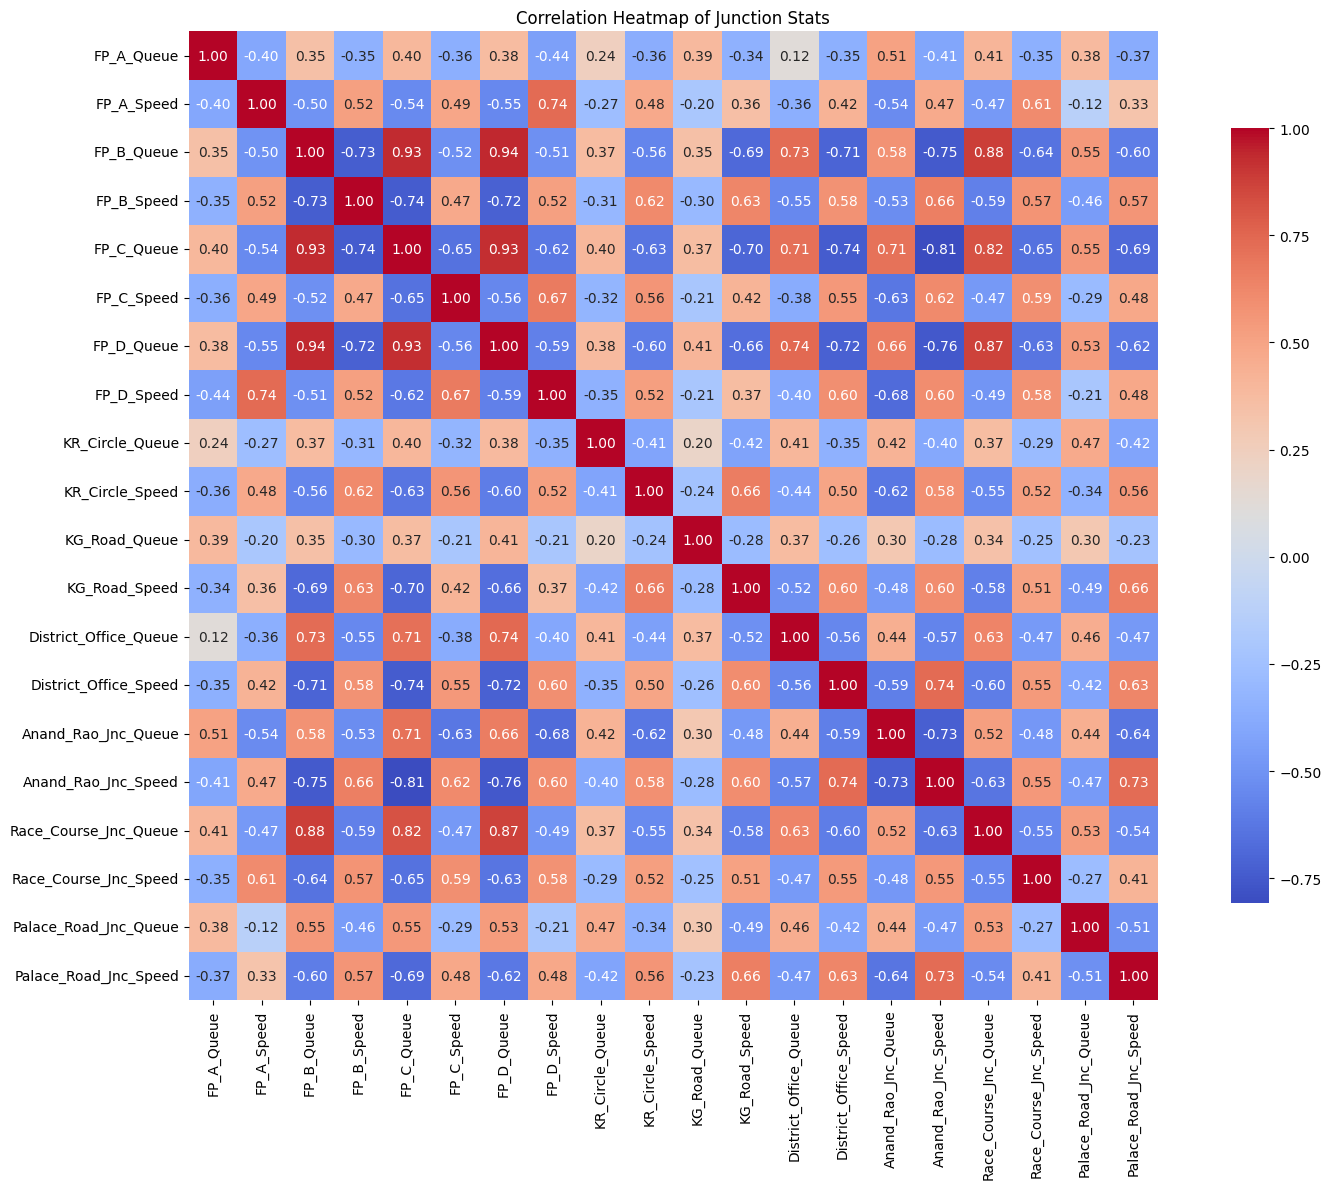

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop 'Time' column if it's not relevant for correlation
corr_data = data.drop(columns=['Time'])

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Junction Stats")
plt.tight_layout()
plt.show()



<ipython-input-9-f0c6fb2151a6>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x='Location', y='Queue-Speed Correlation', palette='coolwarm')


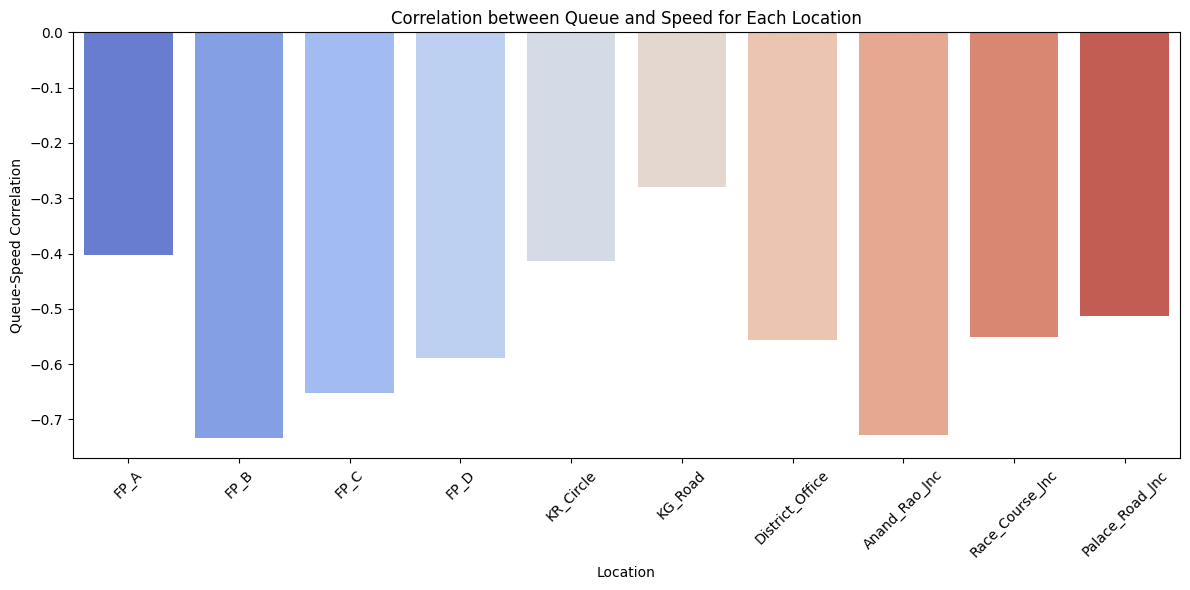

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop 'Time'
df = data.drop(columns=['Time'])

# Match queue-speed pairs
queue_speed_pairs = []
corr_values = []

for col in df.columns:
    if col.endswith('_Queue'):
        location = col.replace('_Queue', '')
        speed_col = location + '_Speed'
        if speed_col in df.columns:
            corr = df[col].corr(df[speed_col])
            queue_speed_pairs.append(location)
            corr_values.append(corr)

# Create a DataFrame for plotting
corr_df = pd.DataFrame({
    'Location': queue_speed_pairs,
    'Queue-Speed Correlation': corr_values
})

# Plot as barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=corr_df, x='Location', y='Queue-Speed Correlation', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Correlation between Queue and Speed for Each Location')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


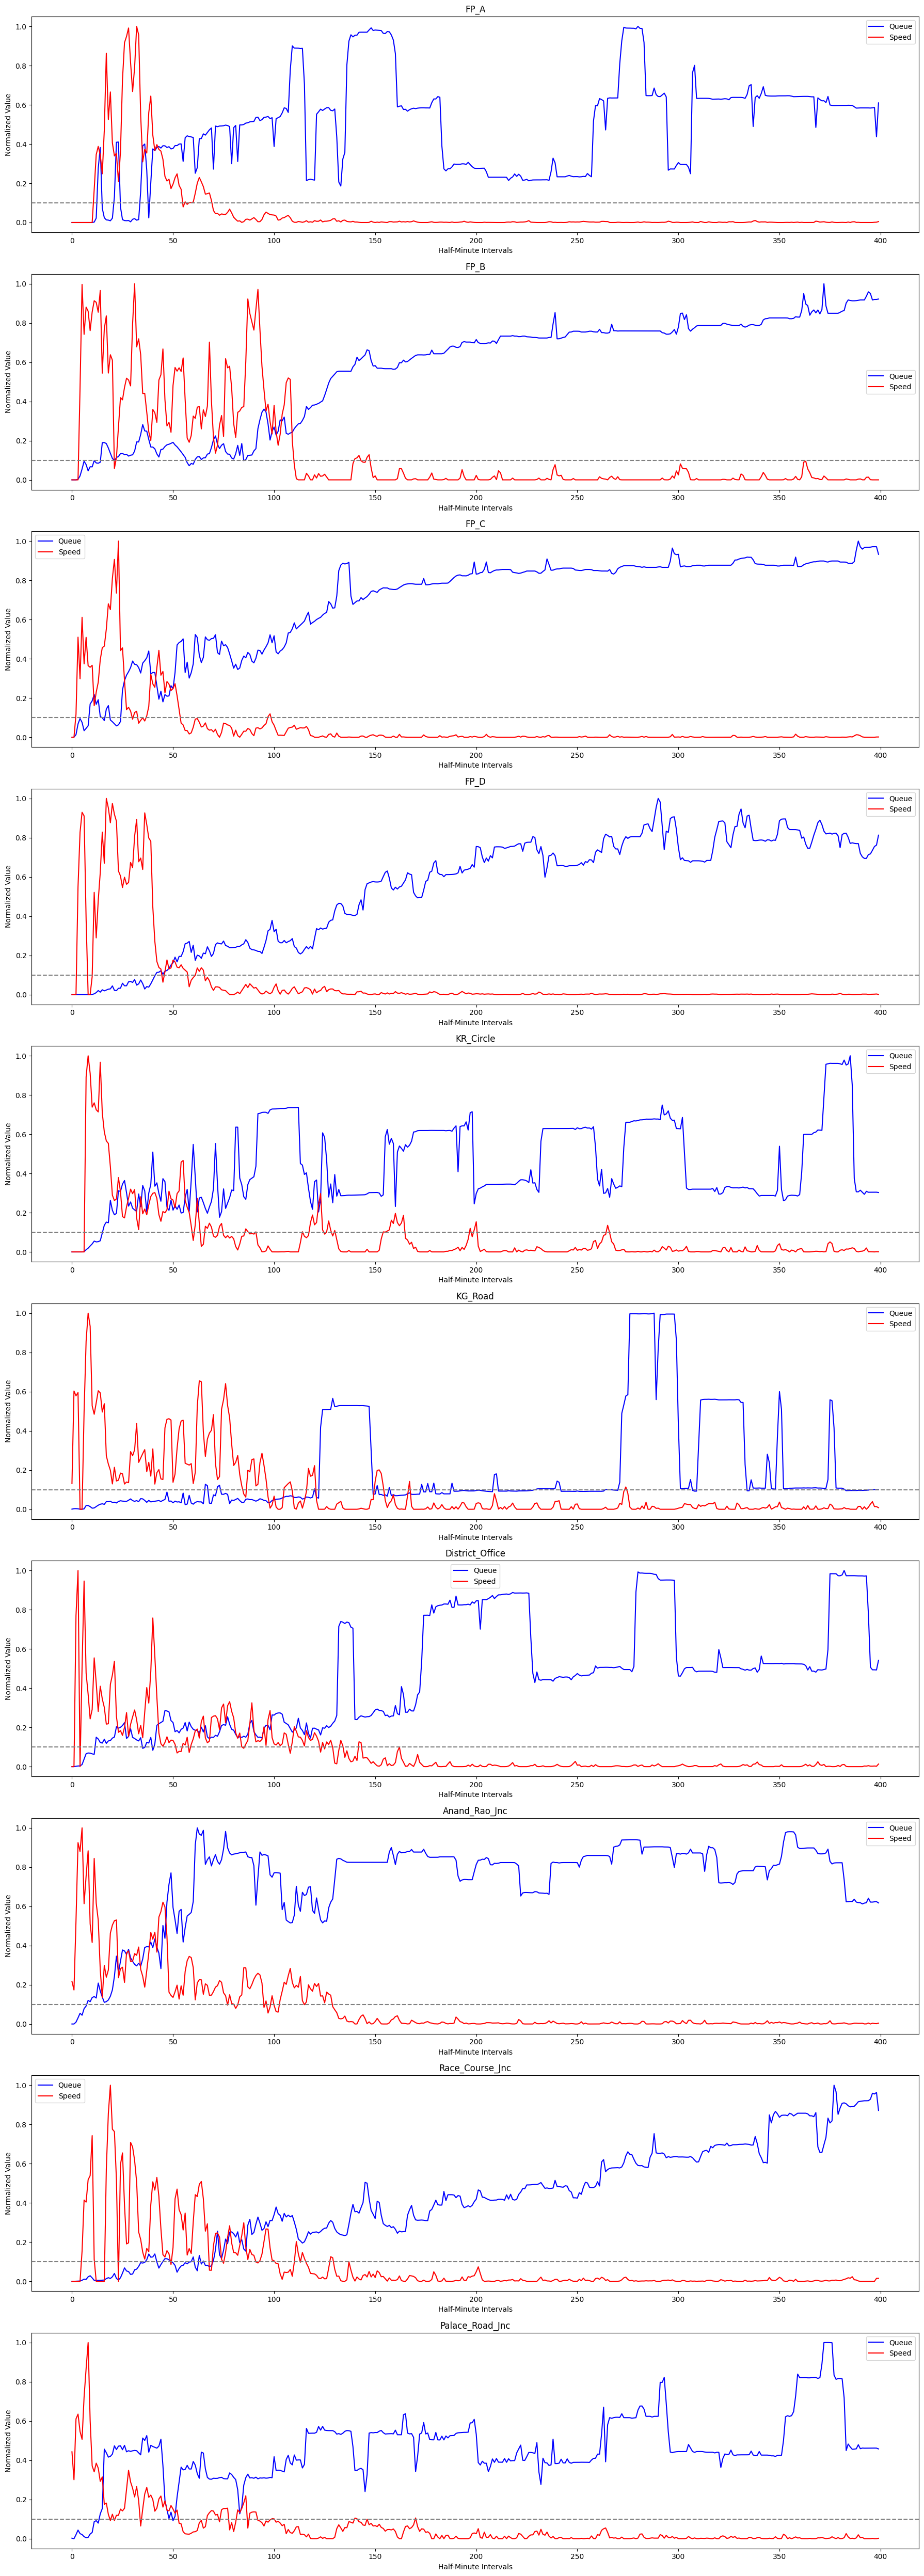

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Select only queue columns + Time
queue_cols = [col for col in data.columns if col.endswith('_Queue')]
df = data[['Time'] + queue_cols].copy()

# Add corresponding speed columns
for col in queue_cols:
    speed_col = col.replace('_Queue', '_Speed')
    df[speed_col] = data[speed_col]

# Resample every 10 rows (~half-minute)
df['Half_Minute'] = df.index // 10
df_resampled = df.groupby('Half_Minute').mean().reset_index()

# Normalize each column (min-max scaling)
for col in queue_cols:
    speed_col = col.replace('_Queue', '_Speed')
    df_resampled[col] = (df_resampled[col] - df_resampled[col].min()) / (df_resampled[col].max() - df_resampled[col].min())
    df_resampled[speed_col] = (df_resampled[speed_col] - df_resampled[speed_col].min()) / (df_resampled[speed_col].max() - df_resampled[speed_col].min())

# Plot settings
n_cols = 3
n_rows = len(queue_cols)
fig, axs = plt.subplots(n_rows, 1, figsize=(18, 5 * n_rows))
axs = axs.flatten()

# Plot each normalized queue and speed
for i, col in enumerate(queue_cols):
    speed_col = col.replace('_Queue', '_Speed')
    axs[i].plot(df_resampled['Half_Minute'], df_resampled[col], label='Queue', color='blue')
    axs[i].plot(df_resampled['Half_Minute'], df_resampled[speed_col], label='Speed', color='red')
    axs[i].axhline(y=0.1, color='gray', linestyle='--')  # Dotted line at y=0.1
    axs[i].set_title(col.replace('_Queue', ''))
    axs[i].set_xlabel('Half-Minute Intervals')
    axs[i].set_ylabel('Normalized Value')
    axs[i].legend()

# Hide extra subplots if any
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()



Preliminary Limits for Junction Jam Detection:

FP_A: 40

FP_B: 3

FP_C: 5

FP_D: 15

KR Circle: 20

KG Road: 15

District Office: 10

Anand Rao: 6

Race Course: 10

Palace Road: 20

Additional Condition:

An average speed of 0.1 is used to determine junction jam.



## FULL SM WITH DYNAMICAL SCALING TO PRINT COUNT, QL, AVG SPEED

In [ ]:
import traci
import math
import csv
import time

# GUI mode toggle
gui_mode = "0"
sumo_binary = "sumo"

# Tracking Locations (x, y, radius, name)
tracking_points = [
    (1152.42, 1127.79, 50.0, "FP_A"),
    (950.87, 810.02, 50.0, "FP_B"),
    (1223.24, 631.01, 50.0, "FP_C"),
    (1432.75, 948.52, 50.0, "FP_D"),
    (1740.61, 719.02, 50.0, "KR_Circle"),
    (766.83, 538.53, 50.0, "KG_Road"),
    (1101.36, 389.54, 75.0, "District_Office"),
    (383.71, 1249.29, 50.0, "Anand_Rao_Jnc"),
    (1176.84, 1667.69, 70.0, "Race_Course_Jnc"),
    (1836.39, 1677.60, 50.0, "Palace_Road_Jnc")
]

# Helper: Check if edge is within a tracking point's radius
def is_edge_inside_circle(edge_id, x_center, y_center, radius):
    try:
        from_junc = traci.edge.getFromJunction(edge_id)
        to_junc = traci.edge.getToJunction(edge_id)
        x_from, y_from = traci.junction.getPosition(from_junc)
        x_to, y_to = traci.junction.getPosition(to_junc)
        return (
            math.hypot(x_from - x_center, y_from - y_center) <= radius or
            math.hypot(x_to - x_center, y_to - y_center) <= radius
        )
    except:
        return False

# Helper: Calculate average queue length percent
def get_queue_length_percentage(edge_id):
    try:
        queue_length = traci.edge.getLastStepVehicleNumber(edge_id)
        lane_id = edge_id + "_0"
        total_length = traci.lane.getLength(lane_id)
        return (queue_length / total_length) * 100 if total_length > 0 else 0
    except:
        return 0

# Update traffic scale dynamically
def update_traffic_scale(time_step):
    hour = (time_step // 3600) % 24
    if hour <= 0:
        scale = 0.317
    elif hour <= 1:
        scale = 0.250
    elif hour <= 2:
        scale = 0.226
    elif hour <= 3:
        scale = 0.200
    elif hour <= 4:
        scale = 0.208
    elif hour <= 5:
        scale = 0.243
    elif hour <= 6:
        scale = 0.293
    elif hour <= 7:
        scale = 0.665
    elif hour <= 8:
        scale = 0.805
    elif hour <= 9:
        scale = 0.876
    elif hour <= 10:
        scale = 0.900
    elif hour <= 11:
        scale = 0.861
    elif hour <= 12:
        scale = 0.873
    elif hour <= 13:
        scale = 0.849
    elif hour <= 14:
        scale = 0.856
    elif hour <= 15:
        scale = 0.837
    elif hour <= 16:
        scale = 0.817
    elif hour <= 17:
        scale = 0.844
    elif hour <= 18:
        scale = 0.797
    elif hour <= 19:
        scale = 0.262
    elif hour <= 20:
        scale = 0.270
    elif hour <= 21:
        scale = 0.257
    elif hour <= 22:
        scale = 0.253
    elif hour <= 23:
        scale = 0.246
    else:
        scale = 0.317  # fallback

    traci.simulation.setScale(scale)

# Start SUMO
traci.start([sumo_binary, "-c", r"/content/osm.sumocfg", "--start"])
time.sleep(2)

# Build edge map for each point
junction_edges_map = {name: [] for _, _, _, name in tracking_points}
for edge_id in traci.edge.getIDList():
    for x, y, radius, name in tracking_points:
        if is_edge_inside_circle(edge_id, x, y, radius):
            junction_edges_map[name].append(edge_id)

# CSV setup
with open("junction_data_race_course.csv", "w", newline="") as csvfile:
    headers = ["Time"]
    for _, _, _, name in tracking_points:
        headers.extend([f"{name}_Count", f"{name}_QueuePct", f"{name}_Speed"])
    writer = csv.writer(csvfile)
    writer.writerow(headers)

    simulation_time = 86400  # 24 hours
    for step in range(simulation_time):
        traci.simulationStep()
        update_traffic_scale(step)

        if step % 60 == 0:
            current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
            hour = (step // 3600) % 24
            print(f"{current_time} : Sim Time: {step}s : Hour: {hour}")

        row = [step]
        for x, y, radius, name in tracking_points:
            count = 0
            speed_sum = 0.0
            for v_id in traci.vehicle.getIDList():
                vx, vy = traci.vehicle.getPosition(v_id)
                if math.hypot(vx - x, vy - y) <= radius:
                    count += 1
                    speed_sum += traci.vehicle.getSpeed(v_id)
            avg_speed = (speed_sum / count) if count > 0 else 0.0

            edges = junction_edges_map[name]
            total_pct = sum(get_queue_length_percentage(eid) for eid in edges)
            avg_queue_pct = (total_pct / len(edges)) if edges else 0

            row.extend([count, round(avg_queue_pct, 2), round(avg_speed, 2)])

        writer.writerow(row)

traci.close()
print("Simulation completed and data saved.")


 Retrying in 1 seconds
2025-04-24 14:25:01 : Sim Time: 0s : Hour: 0
2025-04-24 14:25:04 : Sim Time: 60s : Hour: 0
2025-04-24 14:25:07 : Sim Time: 120s : Hour: 0
2025-04-24 14:25:10 : Sim Time: 180s : Hour: 0
2025-04-24 14:25:14 : Sim Time: 240s : Hour: 0
2025-04-24 14:25:18 : Sim Time: 300s : Hour: 0
2025-04-24 14:25:22 : Sim Time: 360s : Hour: 0
2025-04-24 14:25:25 : Sim Time: 420s : Hour: 0
2025-04-24 14:25:30 : Sim Time: 480s : Hour: 0
2025-04-24 14:25:34 : Sim Time: 540s : Hour: 0
2025-04-24 14:25:37 : Sim Time: 600s : Hour: 0
2025-04-24 14:25:41 : Sim Time: 660s : Hour: 0
2025-04-24 14:25:45 : Sim Time: 720s : Hour: 0
2025-04-24 14:25:49 : Sim Time: 780s : Hour: 0
2025-04-24 14:25:53 : Sim Time: 840s : Hour: 0
2025-04-24 14:25:57 : Sim Time: 900s : Hour: 0
2025-04-24 14:26:01 : Sim Time: 960s : Hour: 0
2025-04-24 14:26:04 : Sim Time: 1020s : Hour: 0
2025-04-24 14:26:08 : Sim Time: 1080s : Hour: 0
2025-04-24 14:26:13 : Sim Time: 1140s : Hour: 0
2025-04-24 14:26:16 : Sim Time: 1200s

In [ ]:
traci.close()

In [ ]:
from google.colab import files
files.download('/content/junction_data_race_course.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file = '/content/junction_data_race_course.csv'

data = pd.read_csv(file)

# Drop the 'Time' column
data

,Time,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,...,District_Office_Speed,Anand_Rao_Jnc_Count,Anand_Rao_Jnc_QueuePct,Anand_Rao_Jnc_Speed,Race_Course_Jnc_Count,Race_Course_Jnc_QueuePct,Race_Course_Jnc_Speed,Palace_Road_Jnc_Count,Palace_Road_Jnc_QueuePct,Palace_Road_Jnc_Speed
0,0,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.00,0,0.0,0.0,0,0.00,0.00
1,1,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.94,0,0.0,0.0,0,0.00,0.00
2,2,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,1.84,0,0.0,0.0,0,0.00,0.00
3,3,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,3.02,0,0.0,0.0,1,0.53,0.00
4,4,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,2,0.03,1.91,0,0.0,0.0,1,0.06,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86395,86395,1,0.09,9.99,0,0.08,0.00,0,0.0,0.0,...,11.68,0,0.01,0.00,0,0.0,0.0,1,0.05,4.63
86396,86396,0,0.09,0.00,0,0.08,0.00,0,0.0,0.0,...,0.00,1,0.01,17.38,0,0.0,0.0,2,0.14,10.65
86397,86397,0,0.09,0.00,1,0.08,18.98,0,0.0,0.0,...,0.00,1,0.01,13.67,0,0.0,0.0,2,0.23,8.77
86398,86398,1,0.09,19.84,1,0.08,19.81,0,0.0,0.0,...,0.00,1,0.01,9.67,0,0.0,0.0,2,0.76,6.85


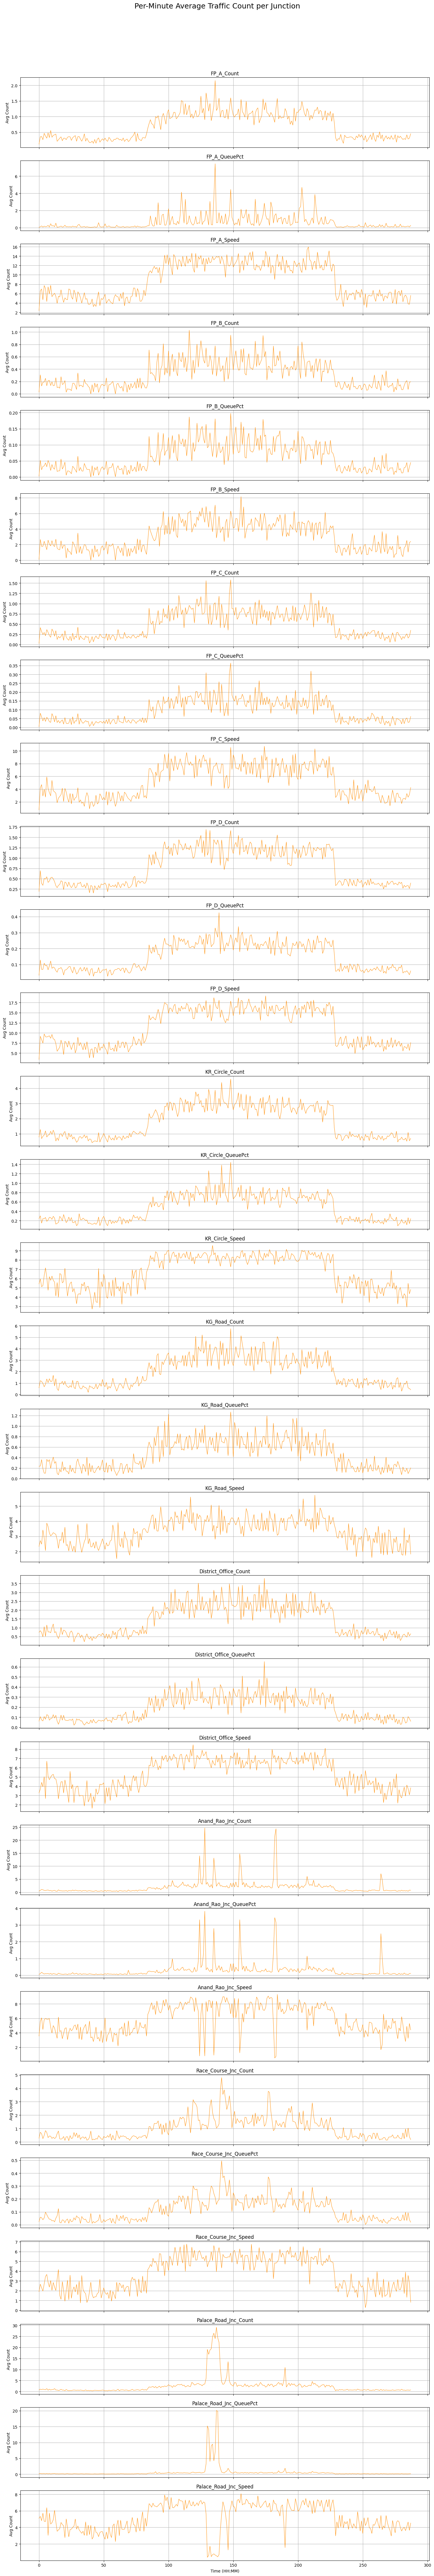

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file = '/content/junction_data_race_course.csv'
data = pd.read_csv(file)

# Drop the 'Time' column
junction_data = data.drop(columns=['Time'])

# Resample per minute: group every 60 rows and take the mean
samples_per_minute = 300 #300 for 5 min
minute_data = junction_data.groupby(junction_data.index // samples_per_minute).mean()

# Create subplots (one for each junction column)
num_junctions = minute_data.shape[1]
fig, axs = plt.subplots(num_junctions, 1, figsize=(15, 3 * num_junctions), sharex=True)

# Plot each junction’s per-minute averaged data
for i, col in enumerate(minute_data.columns):
    axs[i].plot(minute_data.index, minute_data[col], color='darkorange', linewidth=0.8)
    axs[i].set_title(col)
    axs[i].set_ylabel("Avg Count")
    axs[i].grid(True)

# Label the x-axis only for the last subplot
axs[-1].set_xlabel("Time (HH:MM)")

# Improve layout and spacing
fig.suptitle("Per-Minute Average Traffic Count per Junction", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/junction_data_race_course.csv')  # replace with your actual file path

# Define thresholds for each junction
thresholds = {
    "FP_A": 40,
    "FP_B": 3,
    "FP_C": 5,
    "FP_D": 15,
    "KR_Circle": 20,
    "KG_Road": 15,
    "District_Office": 10,
    "Anand_Rao_Jnc": 6,
    "Race_Course_Jnc": 10,
    "Palace_Road_Jnc": 20
}

# Map columns to check
junctions = {
    "FP_A": ("FP_A_QueuePct", "FP_A_Speed"),
    "FP_B": ("FP_B_QueuePct", "FP_B_Speed"),
    "FP_C": ("FP_C_QueuePct", "FP_C_Speed"),
    "FP_D": ("FP_D_QueuePct", "FP_D_Speed"),
    "KR_Circle": ("KR_Circle_QueuePct", "KR_Circle_Speed"),
    "KG_Road": ("KG_Road_QueuePct", "KG_Road_Speed"),
    "District_Office": ("District_Office_QueuePct", "District_Office_Speed"),
    "Anand_Rao_Jnc": ("Anand_Rao_Jnc_QueuePct", "Anand_Rao_Jnc_Speed"),
    "Race_Course_Jnc": ("Race_Course_Jnc_QueuePct", "Race_Course_Jnc_Speed"),
    "Palace_Road_Jnc": ("Palace_Road_Jnc_QueuePct", "Palace_Road_Jnc_Speed"),
}

# Scan each row and check jam conditions
for idx, row in df.iterrows():
    jams = []
    for junction, (queue_col, speed_col) in junctions.items():
        if row[speed_col] < 0.1 and row[queue_col] > thresholds[junction]:
            jams.append(junction)
    if jams:
        print(f"Time {row['Time']}: Jam at {', '.join(jams)}")


Time 662.0: Jam at KG_Road
Time 1913.0: Jam at KG_Road
Time 2143.0: Jam at KG_Road
Time 3263.0: Jam at KG_Road
Time 7431.0: Jam at KG_Road
Time 11365.0: Jam at KG_Road
Time 12325.0: Jam at KG_Road
Time 12834.0: Jam at District_Office
Time 19087.0: Jam at District_Office
Time 19350.0: Jam at KG_Road
Time 23643.0: Jam at KG_Road
Time 26767.0: Jam at KG_Road
Time 27717.0: Jam at District_Office
Time 29148.0: Jam at KG_Road
Time 29569.0: Jam at KG_Road
Time 30444.0: Jam at District_Office
Time 32144.0: Jam at KG_Road
Time 36742.0: Jam at KG_Road
Time 37307.0: Jam at District_Office
Time 38517.0: Jam at KG_Road
Time 38981.0: Jam at Palace_Road_Jnc
Time 39020.0: Jam at Palace_Road_Jnc
Time 39431.0: Jam at Palace_Road_Jnc
Time 41391.0: Jam at Palace_Road_Jnc
Time 41392.0: Jam at Palace_Road_Jnc
Time 41397.0: Jam at Palace_Road_Jnc
Time 41398.0: Jam at Palace_Road_Jnc
Time 41407.0: Jam at Palace_Road_Jnc
Time 41408.0: Jam at Palace_Road_Jnc
Time 41409.0: Jam at Palace_Road_Jnc
Time 41410.0: Ja

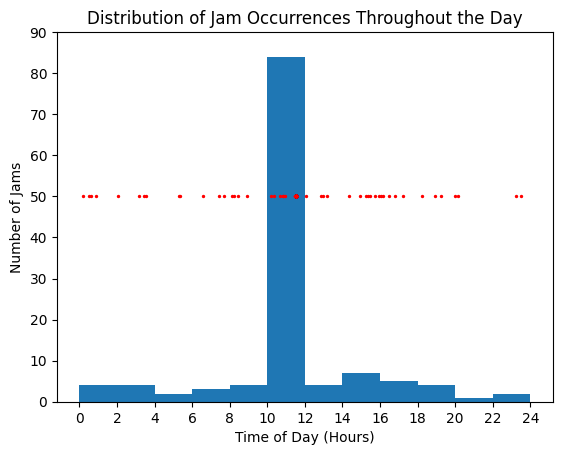

In [71]:
import matplotlib.pyplot as plt

str = '''Time 662.0: Jam at KG_Road
Time 1913.0: Jam at KG_Road
Time 2143.0: Jam at KG_Road
Time 3263.0: Jam at KG_Road
Time 7431.0: Jam at KG_Road
Time 11365.0: Jam at KG_Road
Time 12325.0: Jam at KG_Road
Time 12834.0: Jam at District_Office
Time 19087.0: Jam at District_Office
Time 19350.0: Jam at KG_Road
Time 23643.0: Jam at KG_Road
Time 26767.0: Jam at KG_Road
Time 27717.0: Jam at District_Office
Time 29148.0: Jam at KG_Road
Time 29569.0: Jam at KG_Road
Time 30444.0: Jam at District_Office
Time 32144.0: Jam at KG_Road
Time 36742.0: Jam at KG_Road
Time 37307.0: Jam at District_Office
Time 38517.0: Jam at KG_Road
Time 38981.0: Jam at Palace_Road_Jnc
Time 39020.0: Jam at Palace_Road_Jnc
Time 39431.0: Jam at Palace_Road_Jnc
Time 41391.0: Jam at Palace_Road_Jnc
Time 41392.0: Jam at Palace_Road_Jnc
Time 41397.0: Jam at Palace_Road_Jnc
Time 41398.0: Jam at Palace_Road_Jnc
Time 41407.0: Jam at Palace_Road_Jnc
Time 41408.0: Jam at Palace_Road_Jnc
Time 41409.0: Jam at Palace_Road_Jnc
Time 41410.0: Jam at Palace_Road_Jnc
Time 41411.0: Jam at Palace_Road_Jnc
Time 41412.0: Jam at Palace_Road_Jnc
Time 41413.0: Jam at Palace_Road_Jnc
Time 41414.0: Jam at Palace_Road_Jnc
Time 41415.0: Jam at Palace_Road_Jnc
Time 41416.0: Jam at Palace_Road_Jnc
Time 41417.0: Jam at Palace_Road_Jnc
Time 41418.0: Jam at Palace_Road_Jnc
Time 41419.0: Jam at Palace_Road_Jnc
Time 41420.0: Jam at Palace_Road_Jnc
Time 41421.0: Jam at Palace_Road_Jnc
Time 41422.0: Jam at Palace_Road_Jnc
Time 41423.0: Jam at Palace_Road_Jnc
Time 41424.0: Jam at Palace_Road_Jnc
Time 41425.0: Jam at Palace_Road_Jnc
Time 41426.0: Jam at Palace_Road_Jnc
Time 41427.0: Jam at Palace_Road_Jnc
Time 41428.0: Jam at Palace_Road_Jnc
Time 41429.0: Jam at Palace_Road_Jnc
Time 41430.0: Jam at Palace_Road_Jnc
Time 41454.0: Jam at Palace_Road_Jnc
Time 41455.0: Jam at Palace_Road_Jnc
Time 41456.0: Jam at Palace_Road_Jnc
Time 41457.0: Jam at Palace_Road_Jnc
Time 41458.0: Jam at Palace_Road_Jnc
Time 41459.0: Jam at Palace_Road_Jnc
Time 41460.0: Jam at Palace_Road_Jnc
Time 41461.0: Jam at Palace_Road_Jnc
Time 41462.0: Jam at Palace_Road_Jnc
Time 41463.0: Jam at Palace_Road_Jnc
Time 41464.0: Jam at Palace_Road_Jnc
Time 41465.0: Jam at Palace_Road_Jnc
Time 41470.0: Jam at Palace_Road_Jnc
Time 41471.0: Jam at Palace_Road_Jnc
Time 41472.0: Jam at Palace_Road_Jnc
Time 41473.0: Jam at Palace_Road_Jnc
Time 41474.0: Jam at Palace_Road_Jnc
Time 41487.0: Jam at Palace_Road_Jnc
Time 41488.0: Jam at Palace_Road_Jnc
Time 41489.0: Jam at Palace_Road_Jnc
Time 41490.0: Jam at Palace_Road_Jnc
Time 41491.0: Jam at Palace_Road_Jnc
Time 41492.0: Jam at Palace_Road_Jnc
Time 41493.0: Jam at Palace_Road_Jnc
Time 41494.0: Jam at Palace_Road_Jnc
Time 41495.0: Jam at Palace_Road_Jnc
Time 41496.0: Jam at Palace_Road_Jnc
Time 41497.0: Jam at Palace_Road_Jnc
Time 41519.0: Jam at Palace_Road_Jnc
Time 41520.0: Jam at Palace_Road_Jnc
Time 41521.0: Jam at Palace_Road_Jnc
Time 41522.0: Jam at Palace_Road_Jnc
Time 41535.0: Jam at Palace_Road_Jnc
Time 41536.0: Jam at Palace_Road_Jnc
Time 41537.0: Jam at Palace_Road_Jnc
Time 41566.0: Jam at Palace_Road_Jnc
Time 41567.0: Jam at Palace_Road_Jnc
Time 41568.0: Jam at Palace_Road_Jnc
Time 41569.0: Jam at Palace_Road_Jnc
Time 41570.0: Jam at Palace_Road_Jnc
Time 41571.0: Jam at Palace_Road_Jnc
Time 41572.0: Jam at Palace_Road_Jnc
Time 41573.0: Jam at Palace_Road_Jnc
Time 41574.0: Jam at Palace_Road_Jnc
Time 41575.0: Jam at Palace_Road_Jnc
Time 41576.0: Jam at Palace_Road_Jnc
Time 41577.0: Jam at Palace_Road_Jnc
Time 41578.0: Jam at Palace_Road_Jnc
Time 41579.0: Jam at Palace_Road_Jnc
Time 41580.0: Jam at Palace_Road_Jnc
Time 43369.0: Jam at KG_Road
Time 46356.0: Jam at KG_Road
Time 46737.0: Jam at District_Office
Time 47506.0: Jam at KG_Road
Time 51689.0: Jam at KG_Road
Time 53731.0: Jam at KG_Road
Time 54849.0: Jam at KG_Road
Time 55325.0: Jam at KG_Road
Time 55677.0: Jam at District_Office
Time 56615.0: Jam at District_Office
Time 57425.0: Jam at District_Office
Time 57701.0: Jam at District_Office
Time 58097.0: Jam at KG_Road
Time 59332.0: Jam at KG_Road
Time 60404.0: Jam at KG_Road
Time 61904.0: Jam at KG_Road
Time 65708.0: Jam at District_Office
Time 68195.0: Jam at District_Office
Time 69344.0: Jam at KG_Road
Time 71899.0: Jam at KG_Road
Time 72627.0: Jam at District_Office
Time 83645.0: Jam at KG_Road
Time 84543.0: Jam at KG_Road'''
places = []
yy = []
arr = str.split('\n')

# Extract time stamps and places
for i in range(len(arr)):
    yy.append(float(arr[i].split()[1][:-1]))
    places.append(arr[i].split()[4])



# Create a y array where 1 indicates a jam at that second, 0 otherwise
y = [1]* len(yy)
plt.hist(yy, bins=range(0, 86401, 7200),)
plt.scatter(yy,[i*50 for i in y],color='r',s=2)
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Number of Jams")
plt.ylim(0,90)
plt.title("Distribution of Jam Occurrences Throughout the Day")
plt.xticks([i for i in range(0, 86401, 7200)], [i//3600 for i in range(0, 86401, 7200)])
plt.show()


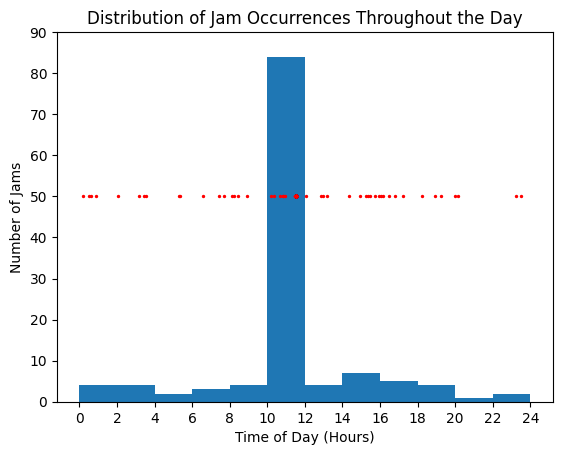

In [70]:
import matplotlib.pyplot as plt

# Create a histogram plot for jam occurrences
plt.hist(yy, bins=range(0, 86401, 7200),)
plt.scatter(yy,[i*50 for i in y],color='r',s=2)
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Number of Jams")
plt.ylim(0,90)
plt.title("Distribution of Jam Occurrences Throughout the Day")
plt.xticks([i for i in range(0, 86401, 7200)], [i//3600 for i in range(0, 86401, 7200)])
plt.show()


In [73]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/junction_data_race_course.csv')  # replace with your actual file path

df

,Time,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,...,District_Office_Speed,Anand_Rao_Jnc_Count,Anand_Rao_Jnc_QueuePct,Anand_Rao_Jnc_Speed,Race_Course_Jnc_Count,Race_Course_Jnc_QueuePct,Race_Course_Jnc_Speed,Palace_Road_Jnc_Count,Palace_Road_Jnc_QueuePct,Palace_Road_Jnc_Speed
0,0,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.00,0,0.0,0.0,0,0.00,0.00
1,1,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,0.94,0,0.0,0.0,0,0.00,0.00
2,2,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,1.84,0,0.0,0.0,0,0.00,0.00
3,3,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,1,0.02,3.02,0,0.0,0.0,1,0.53,0.00
4,4,0,0.00,0.00,0,0.00,0.00,0,0.0,0.0,...,0.00,2,0.03,1.91,0,0.0,0.0,1,0.06,2.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86395,86395,1,0.09,9.99,0,0.08,0.00,0,0.0,0.0,...,11.68,0,0.01,0.00,0,0.0,0.0,1,0.05,4.63
86396,86396,0,0.09,0.00,0,0.08,0.00,0,0.0,0.0,...,0.00,1,0.01,17.38,0,0.0,0.0,2,0.14,10.65
86397,86397,0,0.09,0.00,1,0.08,18.98,0,0.0,0.0,...,0.00,1,0.01,13.67,0,0.0,0.0,2,0.23,8.77
86398,86398,1,0.09,19.84,1,0.08,19.81,0,0.0,0.0,...,0.00,1,0.01,9.67,0,0.0,0.0,2,0.76,6.85


In [76]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/junction_data_race_course.csv')  # replace with your actual file path

# Define thresholds for each junction
thresholds = {
    "FP_A": 40,
    "FP_B": 3,
    "FP_C": 5,
    "FP_D": 15,
    "KR_Circle": 20,
    "KG_Road": 15,
    "District_Office": 10,
    "Anand_Rao_Jnc": 6,
    "Race_Course_Jnc": 10,
    "Palace_Road_Jnc": 20
}

# Extract columns for counts and speeds
junctions = [
    "FP_A", "FP_B", "FP_C", "FP_D", "KR_Circle", "KG_Road", "District_Office",
    "Anand_Rao_Jnc", "Race_Course_Jnc", "Palace_Road_Jnc"
]

# Create a function to check for jams
def check_jam(row, junction, threshold):
    queue_column = f"{junction}_QueuePct"
    speed_column = f"{junction}_Speed"

    # Check if average queue length exceeds the threshold and speed is below 0.1
    if row[queue_column] > threshold and row[speed_column] < 0.1:
        return 1
    else:
        return 0

# Create a new DataFrame with the necessary columns
jam_data = pd.DataFrame()

# Add the 'Time' and the original count columns
jam_data['Time'] = df['Time']
for junction in junctions:
    count_column = f"{junction}_Count"
    jam_column = f"{junction}_Jam"

    # Add the original count columns
    jam_data[count_column] = df[count_column]

    # Apply the check_jam function to create the jam columns
    jam_data[jam_column] = df.apply(lambda row: check_jam(row, junction, thresholds[junction]), axis=1)

# Save to a new CSV file
jam_data.to_csv('race_course_jam_stats.csv', index=False)

print("Jam statistics have been saved to 'race_course_jam_stats.csv'")


Jam statistics have been saved to 'race_course_jam_stats.csv'


In [77]:
jam = r'/content/race_course_jam_stats.csv'
pd.read_csv(jam)

,Time,FP_A_Count,FP_A_Jam,FP_B_Count,FP_B_Jam,FP_C_Count,FP_C_Jam,FP_D_Count,FP_D_Jam,KR_Circle_Count,...,KG_Road_Count,KG_Road_Jam,District_Office_Count,District_Office_Jam,Anand_Rao_Jnc_Count,Anand_Rao_Jnc_Jam,Race_Course_Jnc_Count,Race_Course_Jnc_Jam,Palace_Road_Jnc_Count,Palace_Road_Jnc_Jam
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86395,86395,1,0,0,0,0,0,0,0,1,...,1,0,1,0,0,0,0,0,1,0
86396,86396,0,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,2,0
86397,86397,0,0,1,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,2,0
86398,86398,1,0,1,0,0,0,1,0,1,...,1,0,0,0,1,0,0,0,2,0


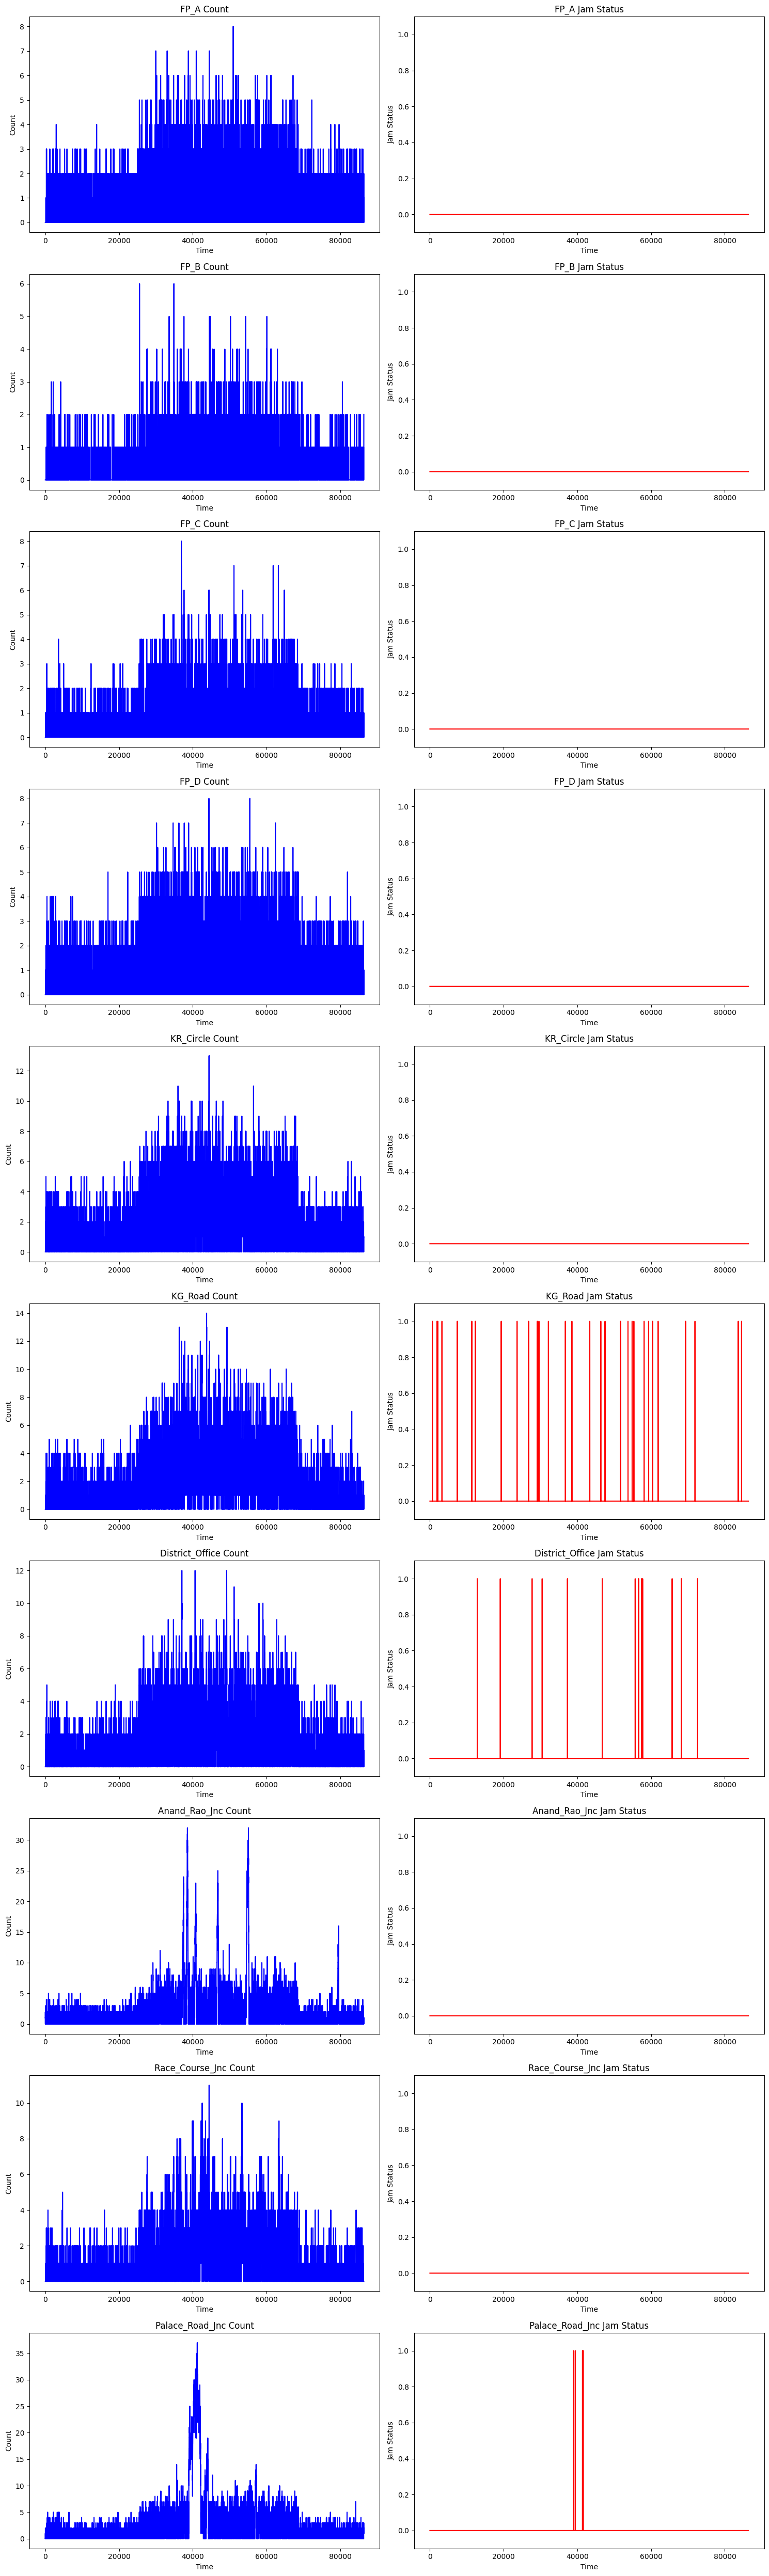

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('race_course_jam_stats.csv')  # Use the path of your saved CSV

# Extract columns for counts and jam status
junctions = [
    "FP_A", "FP_B", "FP_C", "FP_D", "KR_Circle", "KG_Road", "District_Office",
    "Anand_Rao_Jnc", "Race_Course_Jnc", "Palace_Road_Jnc"
]

# Create subplots
fig, axes = plt.subplots(len(junctions), 2, figsize=(15, len(junctions)*5))

# Loop through junctions and plot
for i, junction in enumerate(junctions):
    # Plot Count
    axes[i, 0].plot(df['Time'], df[f"{junction}_Count"], label=f'{junction} Count', color='blue')
    axes[i, 0].set_title(f'{junction} Count')
    axes[i, 0].set_xlabel('Time')
    axes[i, 0].set_ylabel('Count')

    # Plot Jam Status
    axes[i, 1].plot(df['Time'], df[f"{junction}_Jam"], label=f'{junction} Jam', color='red')
    axes[i, 1].set_title(f'{junction} Jam Status')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel('Jam Status')
    axes[i, 1].set_ylim(-0.1, 1.1)  # To ensure the y-axis is between 0 and 1

# Adjust layout
plt.tight_layout()
plt.show()


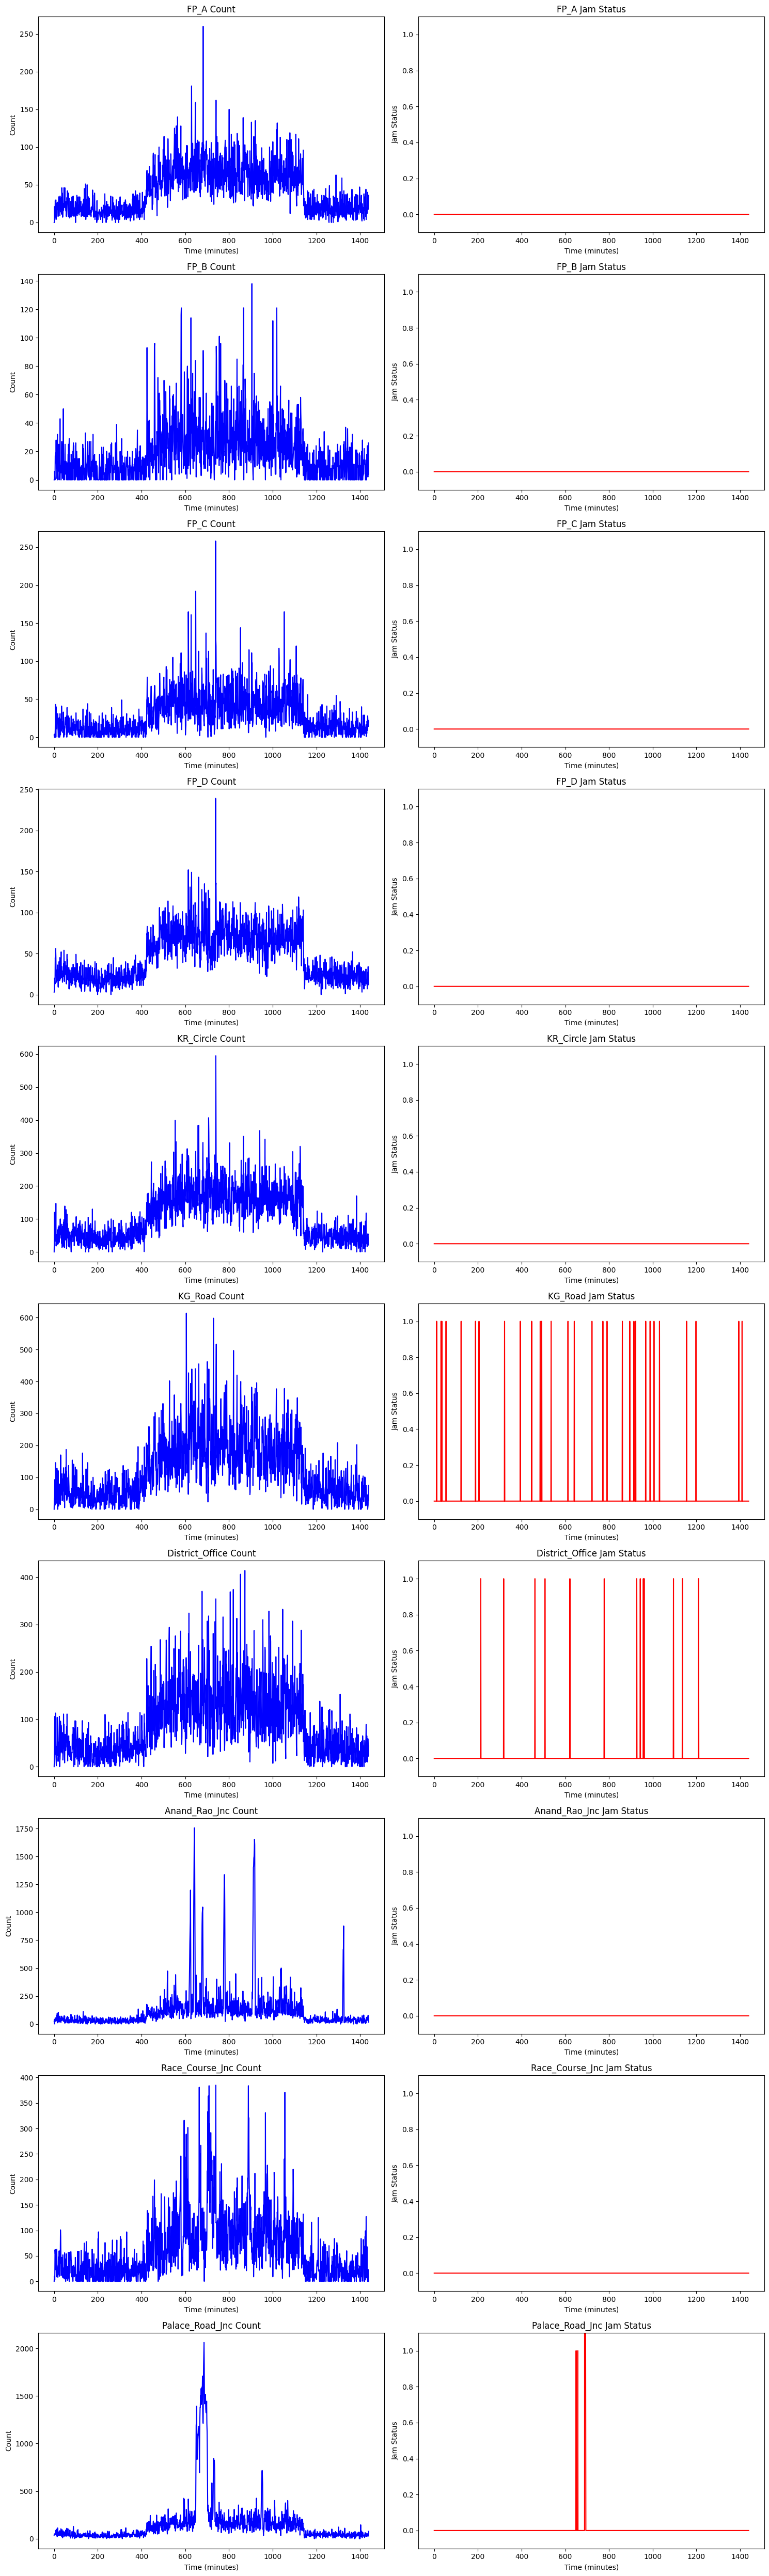

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('race_course_jam_stats.csv')  # Use the path of your saved CSV

# Convert 'Time' to minutes by integer division (since it's in seconds)
df['Minute'] = df['Time'] // 60

# Group by 'Minute' and aggregate the counts and jam status (sum them per minute)
df_resampled = df.groupby('Minute').sum()

# Extract columns for counts and jam status
junctions = [
    "FP_A", "FP_B", "FP_C", "FP_D", "KR_Circle", "KG_Road", "District_Office",
    "Anand_Rao_Jnc", "Race_Course_Jnc", "Palace_Road_Jnc"
]

# Create subplots for visualization
fig, axes = plt.subplots(len(junctions), 2, figsize=(15, len(junctions)*5))

# Loop through junctions and plot
for i, junction in enumerate(junctions):
    # Plot Count
    axes[i, 0].plot(df_resampled.index, df_resampled[f"{junction}_Count"], label=f'{junction} Count', color='blue')
    axes[i, 0].set_title(f'{junction} Count')
    axes[i, 0].set_xlabel('Time (minutes)')
    axes[i, 0].set_ylabel('Count')

    # Plot Jam Status
    axes[i, 1].plot(df_resampled.index, df_resampled[f"{junction}_Jam"], label=f'{junction} Jam', color='red')
    axes[i, 1].set_title(f'{junction} Jam Status')
    axes[i, 1].set_xlabel('Time (minutes)')
    axes[i, 1].set_ylabel('Jam Status')
    axes[i, 1].set_ylim(-0.1, 1.1)  # To ensure the y-axis is between 0 and 1

# Adjust layout
plt.tight_layout()
plt.show()
